# Clustering Techniques

Notebook ini membahas **clustering techniques** sebagai bagian dari unsupervised learning. Berbeda dengan supervised learning yang memiliki target/label, clustering digunakan ketika data tidak memiliki output yang ingin diprediksi, tetapi kita ingin menemukan struktur atau kelompok tersembunyi dalam data.

Materi utama:
- Introduction to clustering
- K-Means clustering
- Hierarchical clustering
- Density-based clustering dengan DBSCAN
- Cluster evaluation metrics
- Choosing the right clustering algorithm
- Advanced clustering techniques
- Practical exercises dengan dataset Iris

## Tujuan Pembelajaran

Setelah mempelajari notebook ini, pembaca diharapkan mampu:

- Memahami konsep dasar clustering dalam unsupervised learning.
- Menjelaskan perbedaan centroid-based, connectivity-based, dan density-based clustering.
- Mengimplementasikan K-Means clustering menggunakan scikit-learn.
- Menggunakan elbow method untuk membantu memilih jumlah cluster.
- Mengimplementasikan Agglomerative Clustering dan membaca dendrogram.
- Mengimplementasikan DBSCAN untuk data non-convex dan noisy.
- Menggunakan k-distance plot untuk membantu memilih parameter `eps`.
- Mengevaluasi cluster menggunakan Silhouette Score, Davies-Bouldin Index, Adjusted Rand Index, dan Calinski-Harabasz Index.
- Memilih algoritma clustering berdasarkan bentuk data, noise, ukuran dataset, dan kebutuhan analisis.
- Menggunakan Spectral Clustering dan Gaussian Mixture Model sebagai teknik clustering lanjutan.

## Persiapan Library

Cell berikut memuat library yang digunakan pada notebook ini. Warning diabaikan agar output notebook tetap rapi.

In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons, make_circles, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN,
    SpectralClustering,
    MiniBatchKMeans
)
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
    calinski_harabasz_score
)

from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(2024)
pd.set_option("display.max_columns", 120)

## Ringkasan Chapter

Clustering adalah teknik unsupervised learning yang digunakan untuk mengelompokkan data berdasarkan kemiripan antar titik data. Karena tidak ada label target, clustering lebih berfokus pada menemukan pola internal atau struktur tersembunyi dari data.

Chapter ini membahas beberapa pendekatan clustering:

| Pendekatan | Contoh Algoritma | Karakteristik |
|---|---|---|
| Centroid-based | K-Means | Membentuk cluster berdasarkan centroid |
| Connectivity-based | Hierarchical/Agglomerative | Membentuk cluster berdasarkan hubungan bertingkat |
| Density-based | DBSCAN | Membentuk cluster berdasarkan kepadatan titik |
| Graph-based | Spectral Clustering | Menggunakan similarity graph |
| Probabilistic | Gaussian Mixture Model | Menggunakan probabilitas keanggotaan cluster |

Clustering dapat digunakan untuk market segmentation, anomaly detection, pengelompokan dokumen, segmentasi gambar, dan eksplorasi dataset tanpa label.

## Introduction to Clustering

Clustering bertujuan membagi data ke dalam beberapa kelompok sehingga data dalam cluster yang sama lebih mirip satu sama lain dibandingkan data di cluster berbeda.

Contoh penggunaan clustering:
- **Market segmentation**: mengelompokkan pelanggan berdasarkan pola pembelian.
- **Anomaly detection**: menemukan titik data yang tidak masuk ke kelompok manapun.
- **Document grouping**: mengelompokkan artikel berdasarkan topik.
- **Image segmentation**: mengelompokkan piksel berdasarkan karakteristik warna atau tekstur.
- **Exploratory data analysis**: memahami struktur awal data tanpa label.

Tantangan utama clustering:
- Menentukan jumlah cluster.
- Menangani noise dan outlier.
- Memilih algoritma yang cocok dengan bentuk data.
- Mengevaluasi hasil clustering tanpa ground truth.
- Menghadapi data berdimensi tinggi.

## Tiga Keluarga Utama Clustering

| Jenis Clustering | Cara Kerja | Kelebihan | Keterbatasan |
|---|---|---|---|
| Centroid-based | Data dikelompokkan berdasarkan jarak ke centroid | Cepat dan sederhana | Kurang cocok untuk cluster non-convex |
| Connectivity-based | Cluster dibangun dari kedekatan antar titik/cluster | Ada struktur hierarki | Kurang scalable untuk data besar |
| Density-based | Cluster dibentuk dari area yang padat | Bisa menangani noise dan bentuk tidak beraturan | Sensitif terhadap parameter `eps` dan `min_samples` |

Pemilihan metode harus menyesuaikan struktur data. Tidak ada satu metode clustering yang selalu paling baik untuk semua kasus.

## Dataset Awal dengan make_blobs

Dataset sintetis dibuat menggunakan `make_blobs`. Dataset ini cocok untuk memperkenalkan K-Means karena bentuk cluster-nya relatif bulat dan terpisah.

Shape dataset: (300, 2)


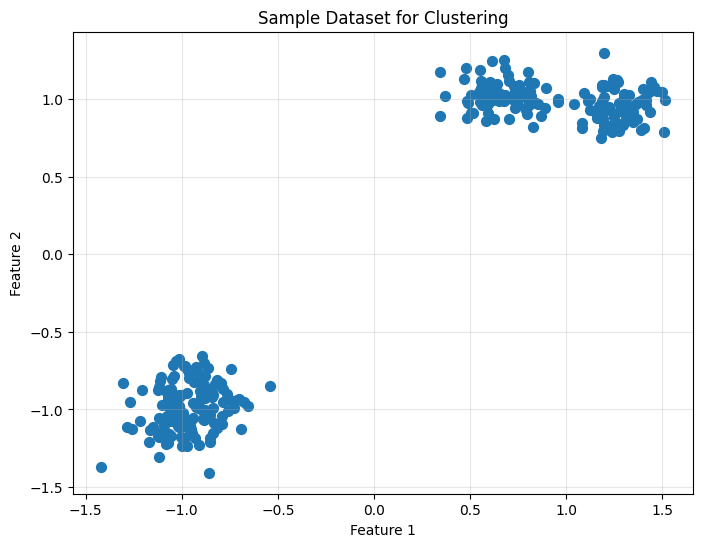

In [2]:
X_blobs_raw, y_blobs_true = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.60,
    random_state=2024
)

X_blobs = StandardScaler().fit_transform(X_blobs_raw)

print("Shape dataset:", X_blobs.shape)

plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], s=50)
plt.title("Sample Dataset for Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(alpha=0.3)
plt.show()

## Analisis Dataset Awal

Dataset terlihat memiliki beberapa kelompok titik yang cukup jelas. Dalam kondisi seperti ini, K-Means sering bekerja dengan baik karena cluster berbentuk cenderung convex dan memiliki pusat yang relatif mudah ditemukan.

Namun, perlu diingat bahwa pada data nyata, bentuk cluster tidak selalu sejelas ini. Karena itu, visualisasi awal sangat penting sebelum memilih algoritma clustering.

## K-Means Clustering

K-Means adalah algoritma clustering berbasis centroid. Algoritma ini membagi data ke dalam $k$ cluster, di mana $k$ harus ditentukan di awal.

Tahapan umum K-Means:

1. Tentukan jumlah cluster $k$.
2. Inisialisasi $k$ centroid.
3. Setiap titik data ditugaskan ke centroid terdekat.
4. Centroid diperbarui sebagai rata-rata dari titik-titik dalam cluster.
5. Langkah 3 dan 4 diulang sampai centroid tidak banyak berubah atau mencapai batas iterasi.

K-Means efisien dan cocok untuk cluster berbentuk bulat/convex, tetapi kurang cocok untuk cluster berbentuk melengkung atau data dengan banyak noise.

## Rumus Jarak Euclidean pada K-Means

K-Means biasanya menggunakan Euclidean distance untuk mengukur kedekatan titik terhadap centroid.

$$
d(x_i, \mu_j) = \sqrt{\sum_{m=1}^{p}(x_{im}-\mu_{jm})^2}
$$

Keterangan:

- $x_i$ = titik data ke-$i$
- $\mu_j$ = centroid cluster ke-$j$
- $p$ = jumlah fitur
- $d(x_i,\mu_j)$ = jarak antara titik data dan centroid

Titik data akan masuk ke cluster dengan centroid terdekat.

## Rumus Objective Function K-Means

K-Means meminimalkan jumlah kuadrat jarak antara setiap titik dan centroid cluster-nya.

$$
J = \sum_{j=1}^{k}\sum_{x_i \in C_j}\|x_i - \mu_j\|^2
$$

Keterangan:

- $J$ = objective function atau inertia
- $k$ = jumlah cluster
- $C_j$ = cluster ke-$j$
- $x_i$ = titik data
- $\mu_j$ = centroid cluster ke-$j$

Nilai $J$ yang lebih kecil menunjukkan titik-titik lebih dekat dengan centroid cluster-nya.

## Implementasi K-Means

Contoh berikut menggunakan `n_clusters=4` karena dataset dibuat dengan 4 pusat cluster.

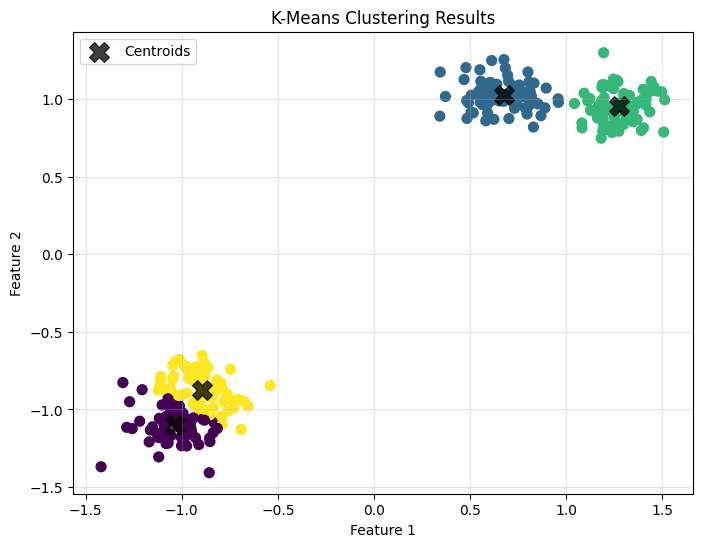

Inertia: 7.2934266782055515


In [3]:
kmeans = KMeans(n_clusters=4, random_state=2024, n_init=10)

y_kmeans = kmeans.fit_predict(X_blobs)
centers = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_kmeans, s=50, cmap="viridis")
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="black",
    s=200,
    alpha=0.75,
    marker="X",
    label="Centroids"
)
plt.title("K-Means Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Inertia:", kmeans.inertia_)

## Analisis Hasil K-Means

K-Means berhasil membagi dataset menjadi empat cluster dan menampilkan centroid sebagai tanda X. Centroid merepresentasikan pusat dari masing-masing cluster.

Namun, K-Means memiliki beberapa keterbatasan:

- Harus menentukan jumlah cluster sejak awal.
- Sensitif terhadap inisialisasi centroid.
- Sensitif terhadap skala fitur.
- Kurang cocok untuk cluster yang tidak berbentuk bulat.
- Kurang baik dalam menangani outlier.

## Elbow Method untuk Memilih k

Elbow method digunakan untuk membantu memilih jumlah cluster. Caranya adalah menghitung inertia untuk berbagai nilai $k$, lalu mencari titik siku atau elbow, yaitu titik ketika penurunan inertia mulai melambat.

Jika setelah nilai tertentu penambahan cluster hanya sedikit menurunkan inertia, nilai tersebut dapat dipertimbangkan sebagai jumlah cluster yang masuk akal.

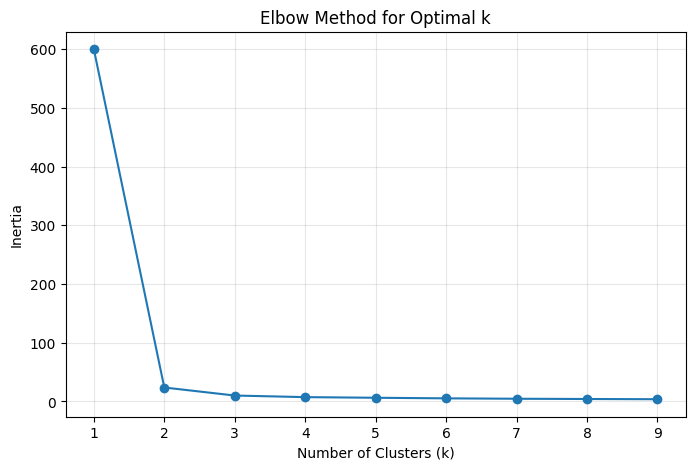

,k,inertia
0,1,600.000000
1,2,23.679432
2,3,9.992623
3,4,7.293427
4,5,6.202993
5,6,5.212868
6,7,4.529888
7,8,4.099088
8,9,3.721588


In [4]:
inertia = []
k_values = range(1, 10)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=2024, n_init=10)
    km.fit(X_blobs)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(alpha=0.3)
plt.show()

pd.DataFrame({
    "k": list(k_values),
    "inertia": inertia
})

## Analisis Elbow Method

Elbow method tidak selalu menghasilkan jawaban yang mutlak. Kadang titik siku terlihat jelas, tetapi kadang juga ambigu. Pada dataset dengan cluster yang sangat terpisah, penurunan inertia biasanya sangat tajam di awal dan mulai melambat setelah jumlah cluster mendekati struktur sebenarnya.

Karena itu, elbow method sebaiknya digunakan bersama metrik lain seperti Silhouette Score dan visualisasi cluster.

## Hierarchical Clustering

Hierarchical clustering membangun struktur cluster bertingkat. Pendekatan yang paling umum adalah **agglomerative clustering**, yaitu pendekatan bottom-up.

Cara kerja agglomerative clustering:

1. Setiap data dimulai sebagai cluster sendiri.
2. Dua cluster terdekat digabung.
3. Proses penggabungan terus dilakukan.
4. Proses berhenti ketika jumlah cluster yang diinginkan tercapai atau jarak tertentu terpenuhi.

Keunggulan hierarchical clustering adalah dapat divisualisasikan menggunakan dendrogram.

## Linkage Criteria pada Hierarchical Clustering

Linkage menentukan cara menghitung jarak antar cluster.

| Linkage | Cara Menghitung Jarak |
|---|---|
| Ward | Meminimalkan peningkatan variance setelah penggabungan |
| Complete | Menggunakan jarak maksimum antar titik dari dua cluster |
| Average | Menggunakan rata-rata jarak antar titik |
| Single | Menggunakan jarak minimum antar titik |

Ward sering digunakan karena cenderung menghasilkan cluster yang compact.

## Implementasi Agglomerative Clustering

Contoh berikut menerapkan Agglomerative Clustering pada dataset blob yang sama.

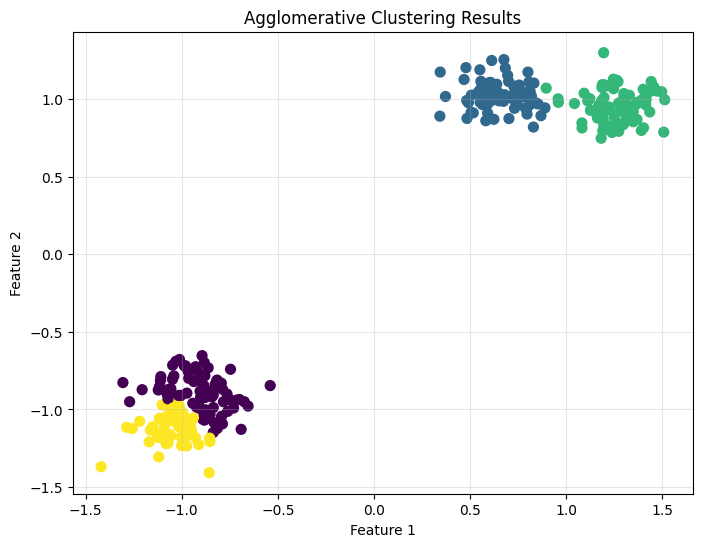

In [5]:
agg = AgglomerativeClustering(n_clusters=4)

y_agg = agg.fit_predict(X_blobs)

plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_agg, cmap="viridis", s=50)
plt.title("Agglomerative Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(alpha=0.3)
plt.show()

## Dendrogram

Dendrogram adalah visualisasi struktur hierarki cluster. Bagian bawah dendrogram menunjukkan data individual, sedangkan bagian atas menunjukkan proses penggabungan cluster.

Dendrogram membantu menentukan jumlah cluster dengan memilih tinggi pemotongan. Jika terdapat gap besar pada jarak penggabungan, gap tersebut bisa menjadi indikasi jumlah cluster yang natural.

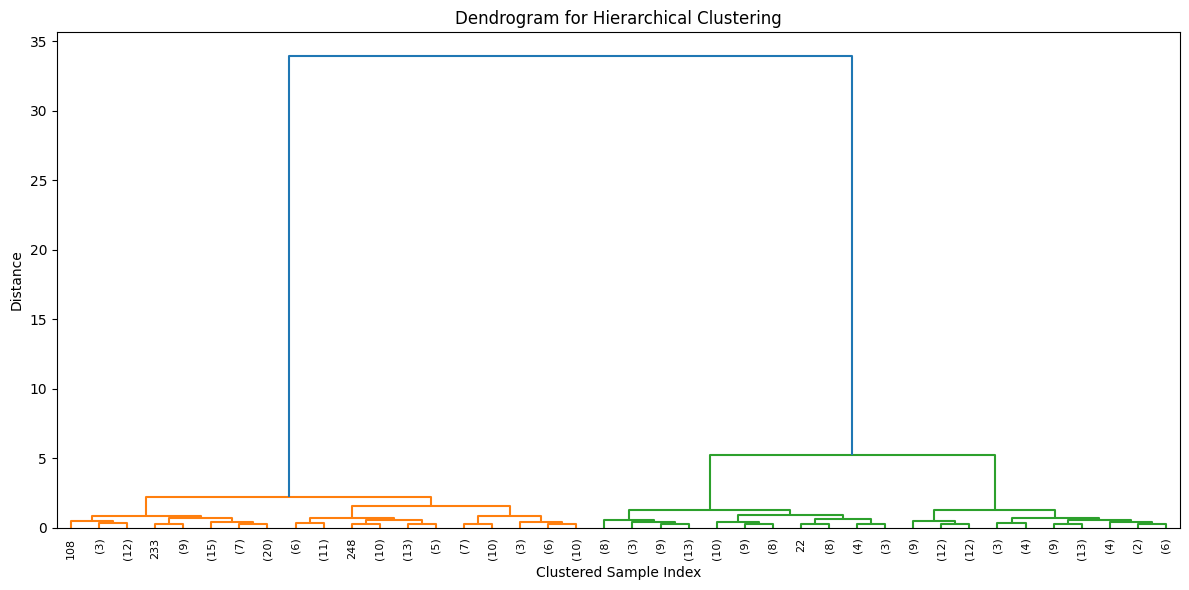

In [6]:
linked = linkage(X_blobs, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(
    linked,
    leaf_rotation=90,
    leaf_font_size=8,
    truncate_mode="lastp",
    p=40
)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Clustered Sample Index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

## Analisis Hierarchical Clustering

Agglomerative clustering berguna ketika kita ingin memahami hubungan bertingkat antar data. Dendrogram memberi gambaran bagaimana data bergabung dari titik individu menjadi cluster besar.

Namun, hierarchical clustering memiliki kelemahan pada skalabilitas. Untuk dataset besar, metode ini bisa lebih lambat dibanding K-Means.

## DBSCAN

DBSCAN adalah clustering berbasis density. Berbeda dari K-Means, DBSCAN tidak membutuhkan jumlah cluster di awal. Algoritma ini membentuk cluster berdasarkan area yang memiliki kepadatan titik tinggi.

DBSCAN cocok untuk:
- Cluster berbentuk non-convex.
- Data dengan noise/outlier.
- Dataset dengan cluster yang tidak bulat.

Parameter utama:
- `eps`: radius neighborhood.
- `min_samples`: jumlah minimum titik agar suatu area dianggap dense.

## Konsep Core, Border, dan Noise Points

DBSCAN membagi titik data menjadi tiga kategori:

| Jenis Titik | Penjelasan |
|---|---|
| Core point | Memiliki minimal `min_samples` titik dalam radius `eps` |
| Border point | Berada dalam neighborhood core point, tetapi tidak cukup dense |
| Noise point | Tidak termasuk core maupun border point |

Noise point biasanya diberi label `-1`.

## Rumus Neighborhood DBSCAN

Neighborhood dari titik $x_i$ dengan radius $\epsilon$ dapat ditulis sebagai:

$$
N_{\epsilon}(x_i)=\{x_j \mid d(x_i,x_j)\le \epsilon\}
$$

Keterangan:

- $N_{\epsilon}(x_i)$ = himpunan tetangga titik $x_i$ dalam radius $\epsilon$
- $d(x_i,x_j)$ = jarak antara $x_i$ dan $x_j$
- $\epsilon$ = radius neighborhood

Sebuah titik menjadi core point jika:

$$
|N_{\epsilon}(x_i)| \ge MinPts
$$

Keterangan:

- $MinPts$ = nilai `min_samples`

## Dataset make_moons untuk DBSCAN

Dataset `make_moons` memiliki bentuk bulan sabit. Dataset seperti ini kurang cocok untuk K-Means, tetapi cocok untuk DBSCAN karena cluster-nya tidak berbentuk bulat.

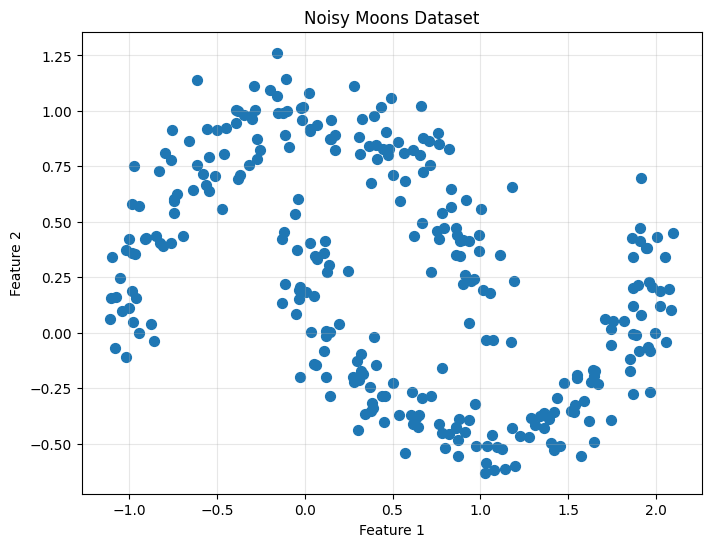

In [7]:
X_moons_db, y_moons_true = make_moons(
    n_samples=300,
    noise=0.1,
    random_state=2024
)

plt.figure(figsize=(8, 6))
plt.scatter(X_moons_db[:, 0], X_moons_db[:, 1], s=50)
plt.title("Noisy Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(alpha=0.3)
plt.show()

## Implementasi DBSCAN

Contoh berikut menggunakan `eps=0.2` dan `min_samples=5`.

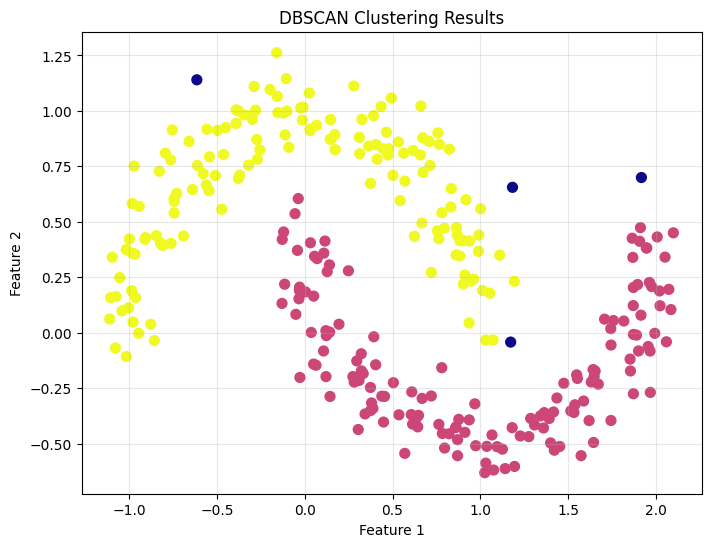

,cluster_label,count
0,-1,4
1,0,150
2,1,146


In [8]:
dbscan = DBSCAN(eps=0.2, min_samples=5)

y_db = dbscan.fit_predict(X_moons_db)

plt.figure(figsize=(8, 6))
plt.scatter(X_moons_db[:, 0], X_moons_db[:, 1], c=y_db, cmap="plasma", s=50)
plt.title("DBSCAN Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(alpha=0.3)
plt.show()

unique_labels, counts = np.unique(y_db, return_counts=True)
pd.DataFrame({
    "cluster_label": unique_labels,
    "count": counts
})

## Analisis DBSCAN

DBSCAN mampu mengenali bentuk cluster melengkung dan dapat menandai titik noise dengan label `-1`. Hal ini membuat DBSCAN kuat untuk data yang tidak cocok dengan asumsi cluster bulat.

Namun, DBSCAN sensitif terhadap parameter `eps`. Jika `eps` terlalu kecil, terlalu banyak titik dianggap noise. Jika `eps` terlalu besar, beberapa cluster dapat tergabung menjadi satu.

## K-Distance Plot untuk Memilih eps

K-distance plot dapat membantu memilih nilai `eps`. Caranya adalah menghitung jarak ke tetangga ke-$k$, di mana $k$ biasanya sama dengan `min_samples`, lalu mencari titik elbow pada grafik.

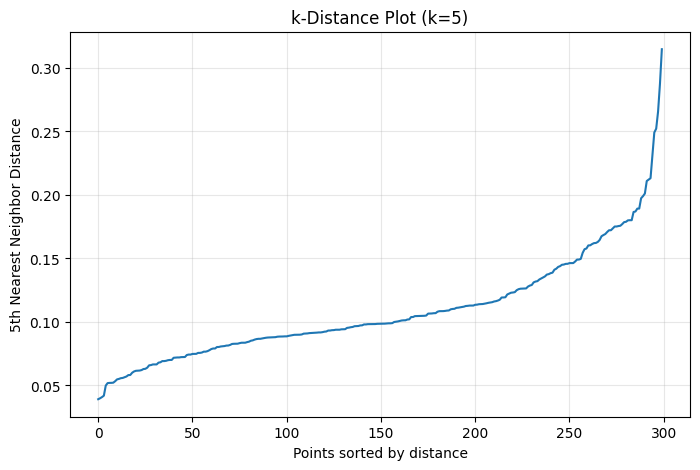

In [9]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_moons_db)
distances, indices = neighbors_fit.kneighbors(X_moons_db)

distances_5th = np.sort(distances[:, 4])

plt.figure(figsize=(8, 5))
plt.plot(distances_5th)
plt.title("k-Distance Plot (k=5)")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.grid(alpha=0.3)
plt.show()

## Cluster Evaluation Metrics

Evaluasi clustering lebih sulit dibanding supervised learning karena sering tidak ada label aktual. Oleh karena itu, metrik clustering dibagi menjadi:

| Jenis Metrik | Contoh | Membutuhkan Ground Truth? |
|---|---|---|
| Internal metric | Silhouette Score, Davies-Bouldin, Calinski-Harabasz | Tidak |
| External metric | Adjusted Rand Index | Ya |

Metrik internal menilai struktur cluster dari data dan label cluster. Metrik external membandingkan cluster dengan label sebenarnya jika tersedia.

## Rumus Silhouette Score

Silhouette score mengukur seberapa mirip suatu titik dengan cluster sendiri dibanding cluster lain.

Untuk titik $i$:

$$
s(i)=\frac{b(i)-a(i)}{\max(a(i),b(i))}
$$

Keterangan:

- $a(i)$ = rata-rata jarak titik $i$ ke titik lain dalam cluster yang sama
- $b(i)$ = rata-rata jarak minimum titik $i$ ke cluster terdekat lainnya
- $s(i)$ = silhouette score untuk titik $i$

Rentang nilai:

- Mendekati 1: cluster baik dan terpisah
- Mendekati 0: titik berada dekat boundary
- Negatif: kemungkinan salah cluster

## Rumus Davies-Bouldin Index

Davies-Bouldin Index mengukur rata-rata kemiripan setiap cluster dengan cluster lain yang paling mirip.

$$
DB = \frac{1}{k}\sum_{i=1}^{k}\max_{j\ne i}
\left(
\frac{S_i+S_j}{M_{ij}}
\right)
$$

Keterangan:

- $k$ = jumlah cluster
- $S_i$ = rata-rata jarak titik dalam cluster $i$ terhadap centroid-nya
- $M_{ij}$ = jarak antara centroid cluster $i$ dan $j$

Nilai lebih kecil menunjukkan cluster lebih baik.

## Rumus Adjusted Rand Index

Adjusted Rand Index membandingkan hasil clustering dengan label ground truth dan mengoreksi hasil karena peluang acak.

$$
ARI =
\frac{RI - Expected(RI)}
{max(RI) - Expected(RI)}
$$

Keterangan:

- $RI$ = Rand Index
- $Expected(RI)$ = nilai Rand Index yang diharapkan secara acak

Rentang nilai ARI umumnya dari -1 sampai 1. Nilai 1 berarti hasil clustering cocok sempurna dengan label aktual.

## Menghitung Evaluasi Clustering

Contoh berikut mengevaluasi K-Means pada dataset blob menggunakan beberapa metrik.

In [10]:
X_eval, y_eval_true = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.60,
    random_state=2024
)

X_eval_scaled = StandardScaler().fit_transform(X_eval)

kmeans_eval = KMeans(n_clusters=4, random_state=2024, n_init=10)
y_eval_kmeans = kmeans_eval.fit_predict(X_eval_scaled)

sil_score = silhouette_score(X_eval_scaled, y_eval_kmeans)
db_index = davies_bouldin_score(X_eval_scaled, y_eval_kmeans)
ari = adjusted_rand_score(y_eval_true, y_eval_kmeans)
ch_score = calinski_harabasz_score(X_eval_scaled, y_eval_kmeans)

pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Adjusted Rand Index",
        "Calinski-Harabasz Index"
    ],
    "Value": [sil_score, db_index, ari, ch_score],
    "Interpretation": [
        "Higher is better",
        "Lower is better",
        "Higher is better",
        "Higher is better"
    ]
})

,Metric,Value,Interpretation
0,Silhouette Score,0.530464,Higher is better
1,Davies-Bouldin Index,0.727467,Lower is better
2,Adjusted Rand Index,0.795300,Higher is better
3,Calinski-Harabasz Index,8018.231276,Higher is better


## Membandingkan Jumlah Cluster dengan Metrik

Metrik dapat digunakan untuk membandingkan hasil pada berbagai jumlah cluster. Pada contoh berikut, K-Means diuji dengan beberapa nilai $k$.

In [11]:
metric_results = []

for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=2024, n_init=10)
    labels = model.fit_predict(X_eval_scaled)

    metric_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_eval_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_eval_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_eval_scaled, labels)
    })

metric_df = pd.DataFrame(metric_results)
metric_df

,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,23.679432,0.879726,0.180515,7252.856819
1,3,9.992623,0.783525,0.355605,8768.077741
2,4,7.293427,0.530464,0.727467,8018.231276
3,5,6.202993,0.536889,0.719041,7059.903254
4,6,5.212868,0.457854,0.818699,6709.067954
5,7,4.529888,0.396290,0.935152,6420.512379
6,8,4.099088,0.375395,0.902497,6064.173038
7,9,3.721588,0.369132,0.898815,5830.001294


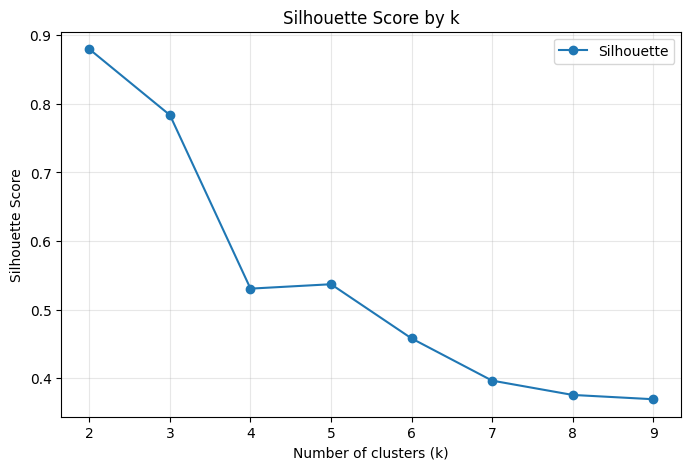

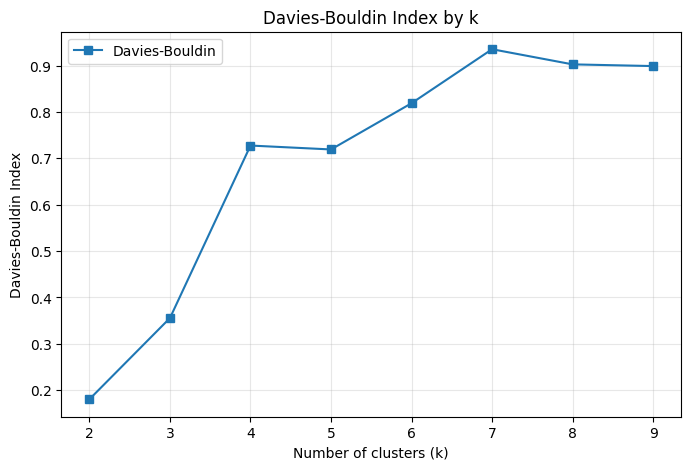

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(metric_df["k"], metric_df["silhouette"], marker="o", label="Silhouette")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by k")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(metric_df["k"], metric_df["davies_bouldin"], marker="s", label="Davies-Bouldin")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin Index by k")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Choosing the Right Clustering Algorithm

Pemilihan algoritma clustering sangat bergantung pada karakteristik data.

| Data Characteristic | Recommended Algorithm |
|---|---|
| Convex clusters | K-Means |
| Non-convex clusters | DBSCAN, Spectral Clustering |
| Presence of noise/outliers | DBSCAN |
| Small datasets | Hierarchical Clustering |
| Large datasets | K-Means, MiniBatchKMeans |
| Overlapping elliptical clusters | Gaussian Mixture Model |
| High-dimensional data | PCA terlebih dahulu, lalu clustering |

Sebelum memilih algoritma, data sebaiknya divisualisasikan agar bentuk dan distribusinya dapat dipahami.

## Visualisasi Beberapa Struktur Data

Tiga dataset sintetis digunakan untuk menunjukkan bahwa bentuk data memengaruhi pilihan algoritma:

- Gaussian blobs
- Moons
- Nested circles

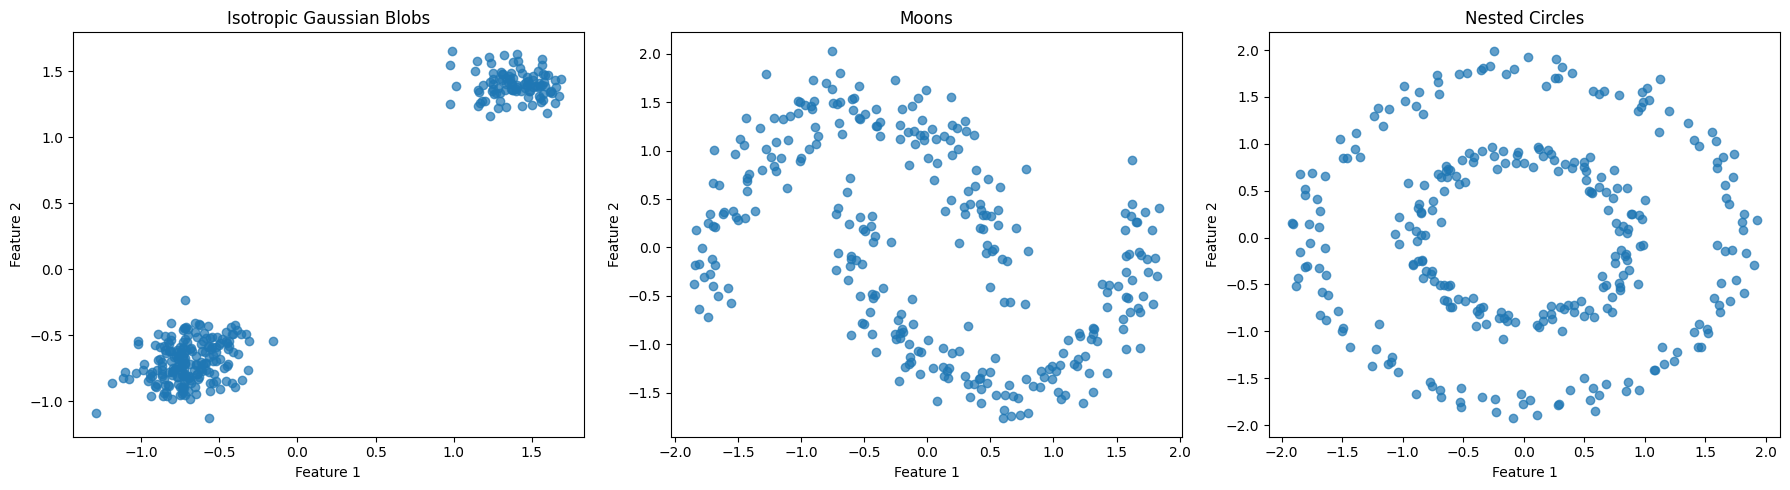

In [13]:
X_choice_blobs, _ = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.6,
    random_state=2024
)

X_choice_moons, _ = make_moons(
    n_samples=300,
    noise=0.1,
    random_state=2024
)

X_choice_circles, _ = make_circles(
    n_samples=300,
    noise=0.05,
    factor=0.5,
    random_state=2024
)

X_choice_blobs = StandardScaler().fit_transform(X_choice_blobs)
X_choice_moons = StandardScaler().fit_transform(X_choice_moons)
X_choice_circles = StandardScaler().fit_transform(X_choice_circles)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].scatter(X_choice_blobs[:, 0], X_choice_blobs[:, 1], alpha=0.7)
axs[0].set_title("Isotropic Gaussian Blobs")
axs[0].set_xlabel("Feature 1")
axs[0].set_ylabel("Feature 2")

axs[1].scatter(X_choice_moons[:, 0], X_choice_moons[:, 1], alpha=0.7)
axs[1].set_title("Moons")
axs[1].set_xlabel("Feature 1")
axs[1].set_ylabel("Feature 2")

axs[2].scatter(X_choice_circles[:, 0], X_choice_circles[:, 1], alpha=0.7)
axs[2].set_title("Nested Circles")
axs[2].set_xlabel("Feature 1")
axs[2].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

## Perbandingan Algoritma pada Berbagai Struktur Data

K-Means, Agglomerative Clustering, dan DBSCAN diterapkan ke setiap dataset. Tujuannya adalah melihat bagaimana algoritma berbeda merespons bentuk data berbeda.

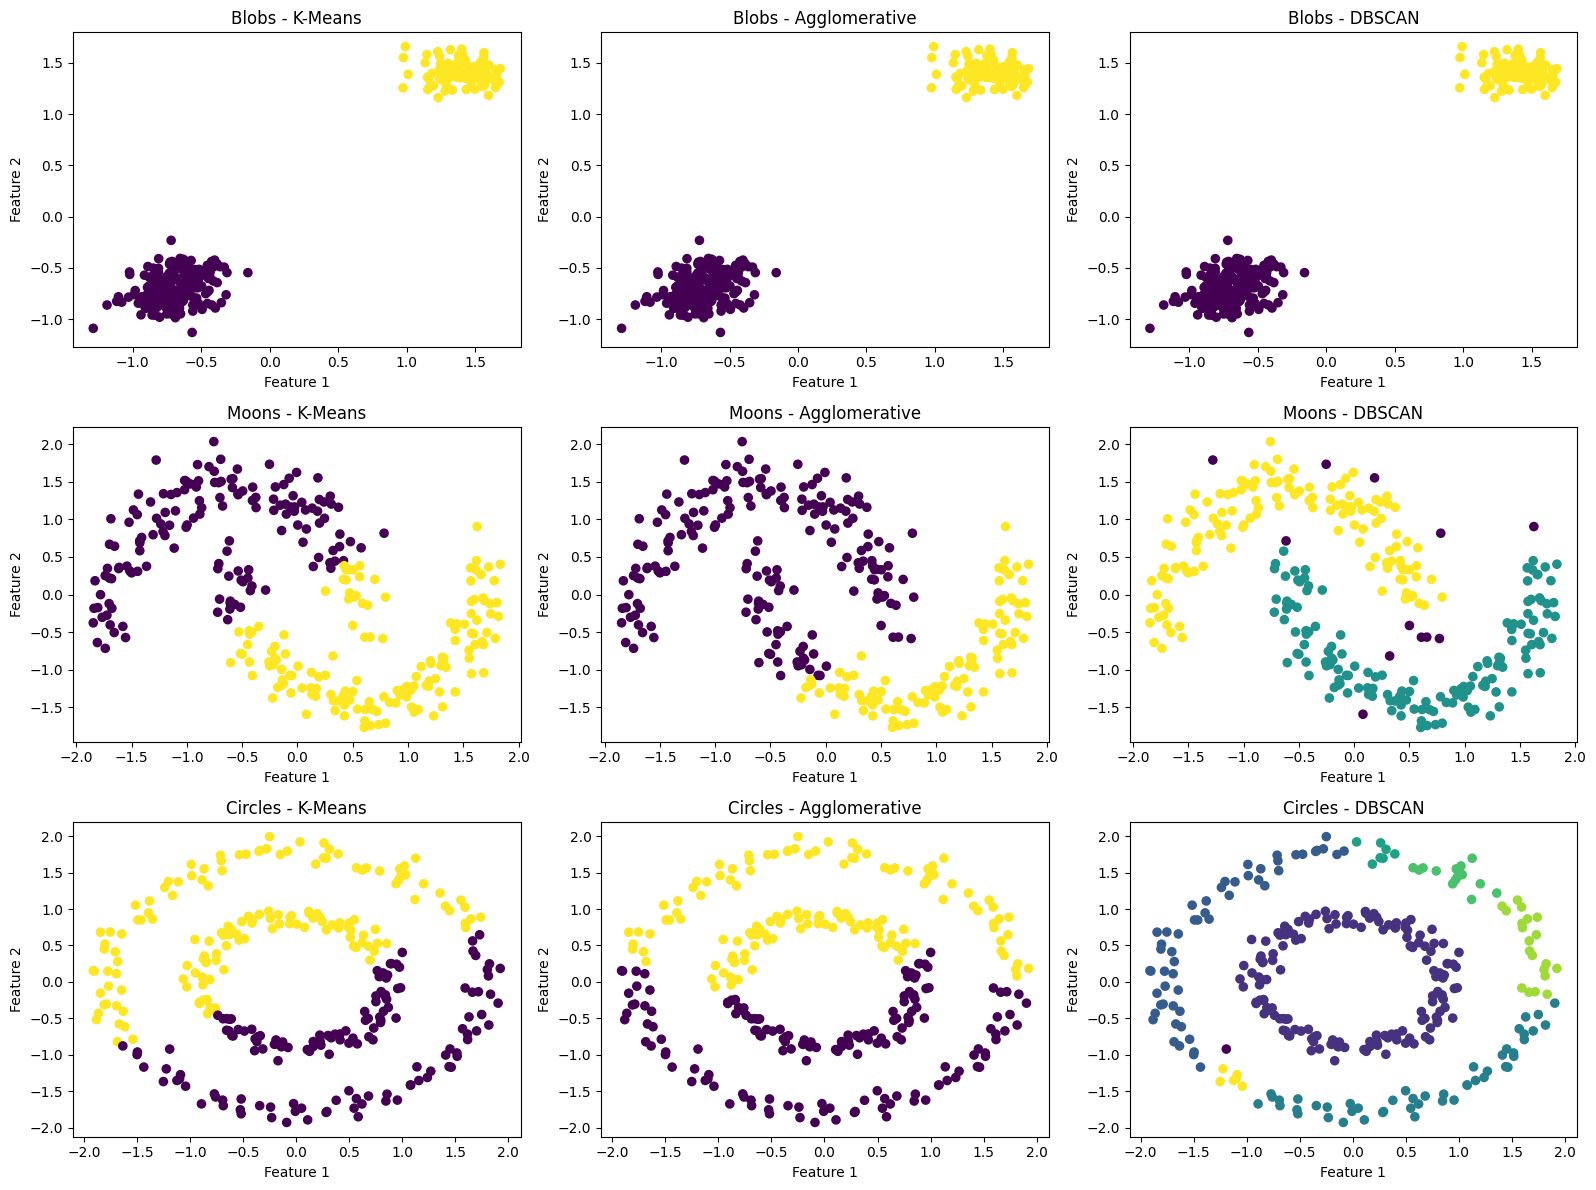

In [14]:
datasets = {
    "Blobs": X_choice_blobs,
    "Moons": X_choice_moons,
    "Circles": X_choice_circles
}

algorithms = {
    "K-Means": KMeans(n_clusters=2, random_state=2024, n_init=10),
    "Agglomerative": AgglomerativeClustering(n_clusters=2),
    "DBSCAN": DBSCAN(eps=0.25, min_samples=5)
}

fig, axes = plt.subplots(len(datasets), len(algorithms), figsize=(16, 12))

for row_idx, (dataset_name, X_data) in enumerate(datasets.items()):
    for col_idx, (algo_name, algo) in enumerate(algorithms.items()):
        labels = algo.fit_predict(X_data)

        ax = axes[row_idx, col_idx]
        ax.scatter(X_data[:, 0], X_data[:, 1], c=labels, cmap="viridis", s=35)
        ax.set_title(f"{dataset_name} - {algo_name}")
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

## Analisis Pemilihan Algoritma

Dari visualisasi, K-Means biasanya bekerja baik pada dataset blobs karena cluster cenderung bulat. DBSCAN lebih baik pada moons atau circles karena mampu mengikuti bentuk cluster non-convex. Agglomerative dapat bekerja baik pada beberapa data kecil, tetapi hasilnya bergantung pada linkage dan struktur jarak.

Kesimpulannya, algoritma tidak bisa dipilih hanya dari popularitas. Struktur data dan tujuan analisis harus menjadi pertimbangan utama.

## Advanced Clustering Techniques

Selain K-Means, hierarchical clustering, dan DBSCAN, scikit-learn juga menyediakan teknik clustering lanjutan seperti:

- Spectral Clustering
- Gaussian Mixture Model

Spectral Clustering cocok untuk data non-convex karena menggunakan similarity graph. Gaussian Mixture Model cocok ketika cluster dianggap berasal dari campuran distribusi Gaussian dan kita ingin probabilitas keanggotaan cluster.

## Spectral Clustering

Spectral Clustering membangun graph kemiripan antar data, kemudian menggunakan informasi dari graph tersebut untuk menemukan struktur cluster.

Langkah umum:

1. Membuat similarity graph.
2. Membentuk matriks yang merepresentasikan hubungan antar titik.
3. Memetakan graph ke ruang berdimensi lebih rendah.
4. Menerapkan K-Means pada representasi baru.

Metode ini efektif untuk cluster non-convex, tetapi dapat lebih mahal secara komputasi dibanding K-Means.

## Gaussian Mixture Model

Gaussian Mixture Model atau GMM adalah metode probabilistic clustering. Berbeda dengan K-Means yang memberikan hard assignment, GMM dapat memberikan probabilitas keanggotaan untuk setiap cluster.

GMM mengasumsikan bahwa data dihasilkan dari campuran beberapa distribusi Gaussian.

## Rumus Gaussian Mixture Model

Distribusi probabilitas GMM dapat ditulis sebagai:

$$
p(x) = \sum_{k=1}^{K}\pi_k \mathcal{N}(x|\mu_k,\Sigma_k)
$$

Keterangan:

- $K$ = jumlah komponen Gaussian
- $\pi_k$ = bobot mixture untuk komponen ke-$k$
- $\mathcal{N}(x|\mu_k,\Sigma_k)$ = distribusi Gaussian dengan mean $\mu_k$ dan covariance $\Sigma_k$
- $\mu_k$ = mean komponen ke-$k$
- $\Sigma_k$ = covariance matrix komponen ke-$k$

Setiap titik dapat memiliki probabilitas berbeda untuk masuk ke masing-masing komponen.

## Implementasi Spectral Clustering dan GMM

Dataset moons digunakan karena memiliki struktur non-convex.

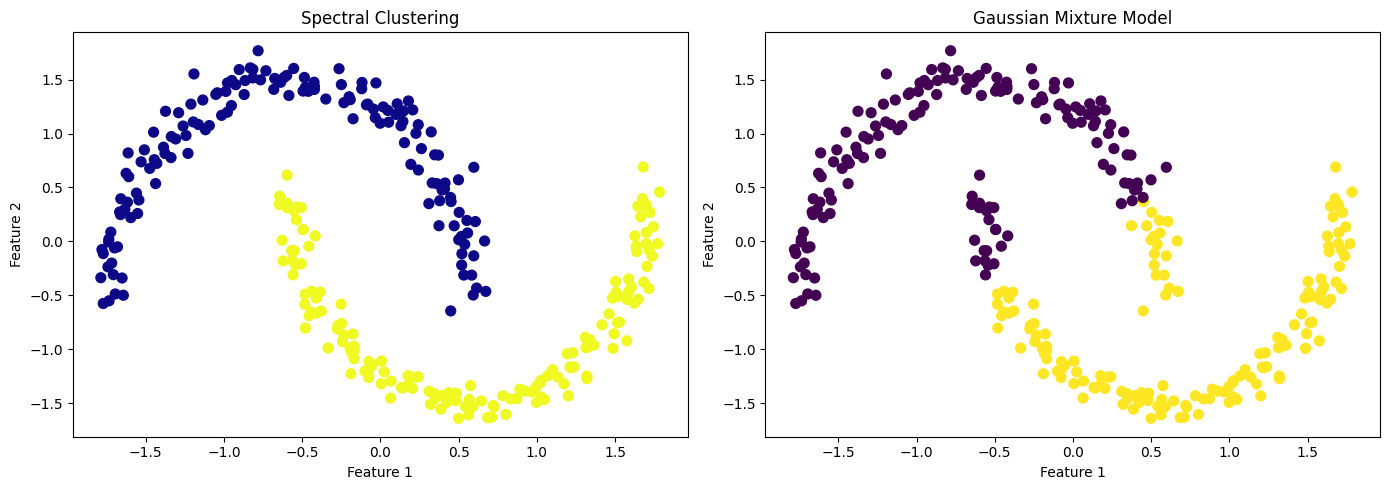

In [15]:
X_advanced, _ = make_moons(
    n_samples=300,
    noise=0.05,
    random_state=2024
)

X_advanced = StandardScaler().fit_transform(X_advanced)

spectral = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    random_state=2024
)

y_spectral = spectral.fit_predict(X_advanced)

gmm = GaussianMixture(
    n_components=2,
    random_state=2024
)

y_gmm = gmm.fit_predict(X_advanced)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(X_advanced[:, 0], X_advanced[:, 1], c=y_spectral, cmap="plasma", s=50)
ax1.set_title("Spectral Clustering")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

ax2.scatter(X_advanced[:, 0], X_advanced[:, 1], c=y_gmm, cmap="viridis", s=50)
ax2.set_title("Gaussian Mixture Model")
ax2.set_xlabel("Feature 1")
ax2.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

## Analisis Spectral Clustering dan GMM

Spectral Clustering biasanya lebih baik dalam mengikuti struktur melengkung karena menggunakan graph kemiripan. GMM lebih fokus pada distribusi probabilistik dan dapat menangani cluster yang overlapping atau elliptical, tetapi kurang ideal untuk bentuk melengkung seperti moons.

Kelebihan GMM adalah adanya probabilitas keanggotaan cluster melalui `predict_proba`.

In [16]:
gmm_probabilities = gmm.predict_proba(X_advanced)

prob_df = pd.DataFrame(
    gmm_probabilities,
    columns=["Probability Cluster 0", "Probability Cluster 1"]
)

prob_df["Predicted Cluster"] = y_gmm
prob_df.head(10)

,Probability Cluster 0,Probability Cluster 1,Predicted Cluster
0,0.377989,0.622011,1
1,0.047391,0.952609,1
2,0.000475,0.999525,1
3,0.999992,0.000008,0
4,0.999856,0.000144,0
5,0.999979,0.000021,0
6,0.000003,0.999997,1
7,0.000146,0.999854,1
8,0.855588,0.144412,0
9,0.101039,0.898961,1


## Visualisasi Ketidakpastian GMM

Jika probabilitas terbesar mendekati 0.5, artinya model relatif tidak yakin pada assignment cluster. Jika mendekati 1.0, artinya model sangat yakin.

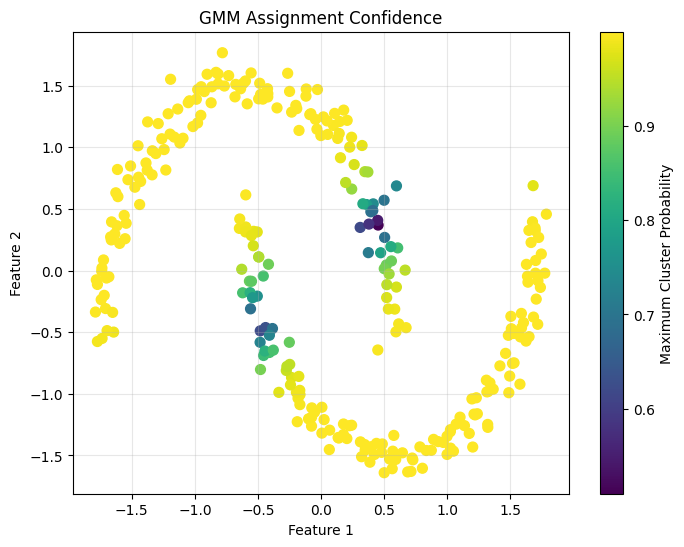

In [17]:
max_prob = gmm_probabilities.max(axis=1)

plt.figure(figsize=(8, 6))
plt.scatter(X_advanced[:, 0], X_advanced[:, 1], c=max_prob, cmap="viridis", s=50)
plt.colorbar(label="Maximum Cluster Probability")
plt.title("GMM Assignment Confidence")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(alpha=0.3)
plt.show()

## Practical Exercise: K-Means pada Iris Dataset

Bagian ini menerapkan K-Means pada dataset Iris. Walaupun Iris memiliki label aktual, label tersebut tidak digunakan saat training. Label hanya digunakan untuk evaluasi external menggunakan ARI.

In [18]:
iris = load_iris()

X_iris = iris.data
y_iris = iris.target

X_iris_scaled = StandardScaler().fit_transform(X_iris)

kmeans_iris = KMeans(n_clusters=3, random_state=2024, n_init=10)
y_iris_cluster = kmeans_iris.fit_predict(X_iris_scaled)

iris_metrics = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Adjusted Rand Index",
        "Calinski-Harabasz Index"
    ],
    "Value": [
        silhouette_score(X_iris_scaled, y_iris_cluster),
        davies_bouldin_score(X_iris_scaled, y_iris_cluster),
        adjusted_rand_score(y_iris, y_iris_cluster),
        calinski_harabasz_score(X_iris_scaled, y_iris_cluster)
    ],
    "Interpretation": [
        "Higher is better",
        "Lower is better",
        "Higher is better",
        "Higher is better"
    ]
})

iris_metrics

,Metric,Value,Interpretation
0,Silhouette Score,0.459948,Higher is better
1,Davies-Bouldin Index,0.833595,Lower is better
2,Adjusted Rand Index,0.620135,Higher is better
3,Calinski-Harabasz Index,241.904402,Higher is better


## Visualisasi Cluster Iris dengan PCA

Karena Iris memiliki 4 fitur, PCA digunakan untuk mereduksi data ke 2 dimensi agar dapat divisualisasikan.

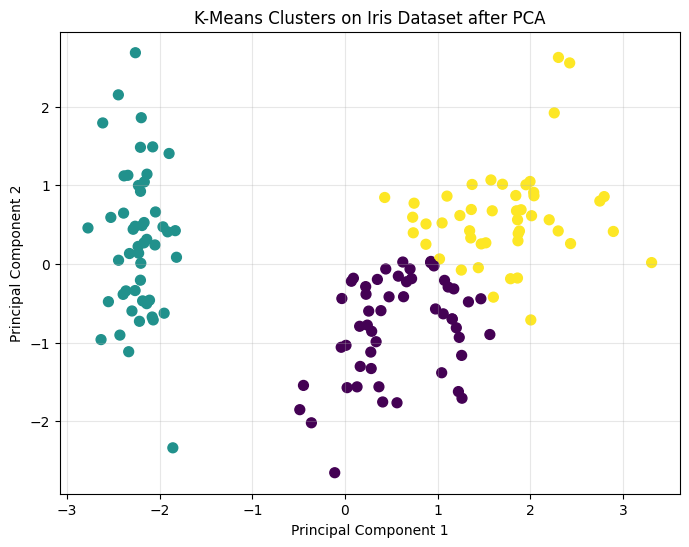

Explained variance ratio: [0.72962445 0.22850762]
Total explained variance: 0.9581320720000166


In [19]:
pca = PCA(n_components=2, random_state=2024)
X_iris_pca = pca.fit_transform(X_iris_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=y_iris_cluster, cmap="viridis", s=50)
plt.title("K-Means Clusters on Iris Dataset after PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(alpha=0.3)
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

## MiniBatchKMeans untuk Dataset Lebih Besar

MiniBatchKMeans adalah variasi K-Means yang menggunakan batch kecil data saat training. Metode ini lebih cepat untuk dataset besar, tetapi hasilnya bisa sedikit berbeda dari K-Means biasa.

In [20]:
X_large, _ = make_blobs(
    n_samples=5000,
    centers=5,
    cluster_std=0.8,
    random_state=2024
)

X_large_scaled = StandardScaler().fit_transform(X_large)

kmeans_large = KMeans(n_clusters=5, random_state=2024, n_init=10)
minibatch = MiniBatchKMeans(n_clusters=5, random_state=2024, batch_size=256, n_init=10)

labels_kmeans_large = kmeans_large.fit_predict(X_large_scaled)
labels_minibatch = minibatch.fit_predict(X_large_scaled)

large_compare = pd.DataFrame({
    "Model": ["KMeans", "MiniBatchKMeans"],
    "Inertia": [kmeans_large.inertia_, minibatch.inertia_],
    "Silhouette": [
        silhouette_score(X_large_scaled, labels_kmeans_large),
        silhouette_score(X_large_scaled, labels_minibatch)
    ]
})

large_compare

,Model,Inertia,Silhouette
0,KMeans,247.804212,0.500611
1,MiniBatchKMeans,255.583258,0.490066


## Ringkasan Konsep Penting

| Konsep | Penjelasan |
|---|---|
| Clustering | Mengelompokkan data tanpa label |
| K-Means | Centroid-based clustering |
| Centroid | Pusat cluster |
| Inertia | Jumlah kuadrat jarak titik ke centroid |
| Elbow Method | Cara visual memilih jumlah cluster |
| Agglomerative Clustering | Hierarchical clustering bottom-up |
| Dendrogram | Visualisasi proses penggabungan cluster |
| DBSCAN | Density-based clustering |
| eps | Radius neighborhood DBSCAN |
| min_samples | Minimum titik untuk area dense |
| Core Point | Titik yang memiliki cukup tetangga dalam radius eps |
| Noise Point | Titik yang tidak masuk cluster |
| Silhouette Score | Evaluasi pemisahan dan kepadatan cluster |
| Davies-Bouldin Index | Evaluasi kemiripan antar cluster |
| Adjusted Rand Index | Evaluasi eksternal jika label benar tersedia |
| Spectral Clustering | Clustering berbasis graph similarity |
| Gaussian Mixture Model | Probabilistic clustering berbasis Gaussian |

## Kesimpulan Chapter

Chapter ini menjelaskan bahwa clustering merupakan teknik penting dalam unsupervised learning untuk menemukan struktur tersembunyi dalam data tanpa label. Beberapa algoritma memiliki asumsi dan kekuatan yang berbeda, sehingga pemilihannya harus disesuaikan dengan bentuk data dan tujuan analisis.

Poin penting dari chapter ini:

- K-Means cocok untuk cluster convex, bulat, dan relatif seimbang.
- K-Means membutuhkan jumlah cluster di awal.
- Elbow method membantu memilih jumlah cluster, tetapi tidak selalu memberikan jawaban mutlak.
- Hierarchical clustering berguna untuk melihat struktur bertingkat melalui dendrogram.
- DBSCAN cocok untuk cluster non-convex dan data yang mengandung noise/outlier.
- DBSCAN tidak membutuhkan jumlah cluster di awal, tetapi sensitif terhadap `eps` dan `min_samples`.
- Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index, dan Adjusted Rand Index dapat membantu mengevaluasi kualitas cluster.
- Spectral Clustering efektif untuk struktur non-convex berbasis graph.
- Gaussian Mixture Model berguna untuk soft clustering dan probabilitas keanggotaan cluster.
- Pada data berdimensi tinggi, PCA dapat membantu visualisasi dan meningkatkan efisiensi clustering.

Secara keseluruhan, clustering bukan proses yang sepenuhnya otomatis. Hasil terbaik biasanya diperoleh melalui kombinasi visualisasi, pemilihan algoritma yang sesuai, tuning parameter, dan evaluasi menggunakan metrik yang relevan.